# RAG Benchmark Results Dashboard

This notebook presents the latest RAG benchmark results in a clear, presentation-ready format.

It includes:
- **Executive summary** of core metrics (Retrieval / Generation / E2E)
- **Failure diagnostics** and root-cause view
- **Breakdowns by category and by SRS document**
- **Visual plots** generated from benchmark outputs
- **Actionable next steps** based on observed data

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

BASE = Path("../data/outputs/evaluation/rag_benchmark")
REPORT = BASE / "report"

overall = pd.read_csv(BASE / "overall_summary.csv")
failure = pd.read_csv(BASE / "diagnostics" / "failure_breakdown.csv")
by_category = pd.read_csv(BASE / "diagnostics" / "metrics_by_category.csv")
ret_by_srs = pd.read_csv(BASE / "retrieval" / "retrieval_summary_by_srs.csv")
gen_by_srs = pd.read_csv(BASE / "generation" / "generation_summary_by_srs.csv")
e2e_by_srs = pd.read_csv(BASE / "e2e" / "e2e_summary_by_srs.csv")
e2e_by_q = pd.read_csv(BASE / "e2e" / "e2e_by_question.csv")
gen_by_q = pd.read_csv(BASE / "generation" / "generation_by_question.csv")

overall_map = dict(zip(overall["metric"], overall["value"]))

def pct(x: float) -> str:
    return f"{x * 100:.2f}%"

print("Loaded benchmark files from:", BASE.resolve())
print("Questions:", int(overall_map.get("questions", len(e2e_by_q))))

Loaded benchmark files from: D:\Qbrainpython\QBrain\rag_lab\data\outputs\evaluation\rag_benchmark
Questions: 60


## Executive Summary

This section provides the metrics that matter most for decision-making:
- Is retrieval working reliably?
- Is generation aligned with expected answers?
- What is the final end-to-end success rate?

In [ ]:
summary = {
    "Questions": int(overall_map.get("questions", len(e2e_by_q))),
    "Retrieval Hit@5": float(overall_map.get("retrieval_hit@5", 0.0)),
    "Retrieval MRR": float(overall_map.get("retrieval_mrr", 0.0)),
    "Generation Accuracy @0.65": float(overall_map.get("generation_accuracy_sim>=0.65", 0.0)),
    "Generation Avg Similarity": float(overall_map.get("generation_avg_similarity", 0.0)),
    "E2E Success": float(overall_map.get("e2e_success_rate", 0.0)),
}

summary_df = pd.DataFrame([summary])
display(summary_df)

pass_count = int((e2e_by_q["failure_type"] == "pass").sum())
fail_count = int((e2e_by_q["failure_type"] != "pass").sum())

print(f"Pass: {pass_count} | Fail: {fail_count}")
print(f"Generation Accuracy: {pct(summary['Generation Accuracy @0.65'])}")
print(f"E2E Success: {pct(summary['E2E Success'])}")

if summary["Retrieval Hit@5"] >= 0.95:
    print("Interpretation: Retrieval is excellent; remaining gap is mainly generation quality/alignment.")
else:
    print("Interpretation: Retrieval still contributes significantly to overall errors.")

,Questions,Retrieval Hit@5,Retrieval MRR,Generation Accuracy @0.65,Generation Avg Similarity,E2E Success
0,60,1.0,1.0,0.783333,0.767639,0.783333


Pass: 47 | Fail: 13
Generation Accuracy: 78.33%
E2E Success: 78.33%
Interpretation: Retrieval is excellent; remaining gap is mainly generation quality/alignment.


## Diagnostics Tables

This section explains **where** failures occur:
- Failure type distribution (Retrieval vs. Generation)
- Performance by question category
- Performance by SRS document

In [ ]:
display(Markdown("### Failure Breakdown"))
display(failure)

if "count" in failure.columns and len(failure) > 0:
    total_fail_rows = failure["count"].sum()
    failure_view = failure.copy()
    failure_view["ratio"] = (failure_view["count"] / total_fail_rows).round(4)
    display(Markdown("Failure ratio"))
    display(failure_view)

display(Markdown("### Metrics by Category"))
display(by_category.sort_values("e2e_success_rate", ascending=False))

display(Markdown("### E2E by SRS"))
display(e2e_by_srs.sort_values("e2e_success_rate", ascending=False))

### Failure Breakdown

,failure_type,count
0,pass,47
1,generation_fail,13


Failure ratio

,failure_type,count,ratio
0,pass,47,0.7833
1,generation_fail,13,0.2167


### Metrics by Category

,category,questions,e2e_success_rate,retrieval_hit_rate,generation_accuracy,avg_similarity
0,direct,60,0.783333,1.0,0.783333,0.767639


### E2E by SRS

,srs_file,questions,e2e_success_rate,retrieval_hit_rate,generation_accuracy
0,2007 - ertms.pdf,12,1.000000,1.0,1.000000
2,2009 - inventory 2.0.pdf,12,0.833333,1.0,0.833333
3,2010 - gparted.pdf,12,0.833333,1.0,0.833333
1,2008 - keepass.pdf,12,0.666667,1.0,0.666667
4,JDECo_SRS.docx[1].pdf,12,0.583333,1.0,0.583333


## Built Plots (Generated from Script)

These figures are ready to use in presentations:
- Overall metric snapshot
- Failure distribution
- Similarity distribution
- Comparison by SRS and category

### overall_metrics.png

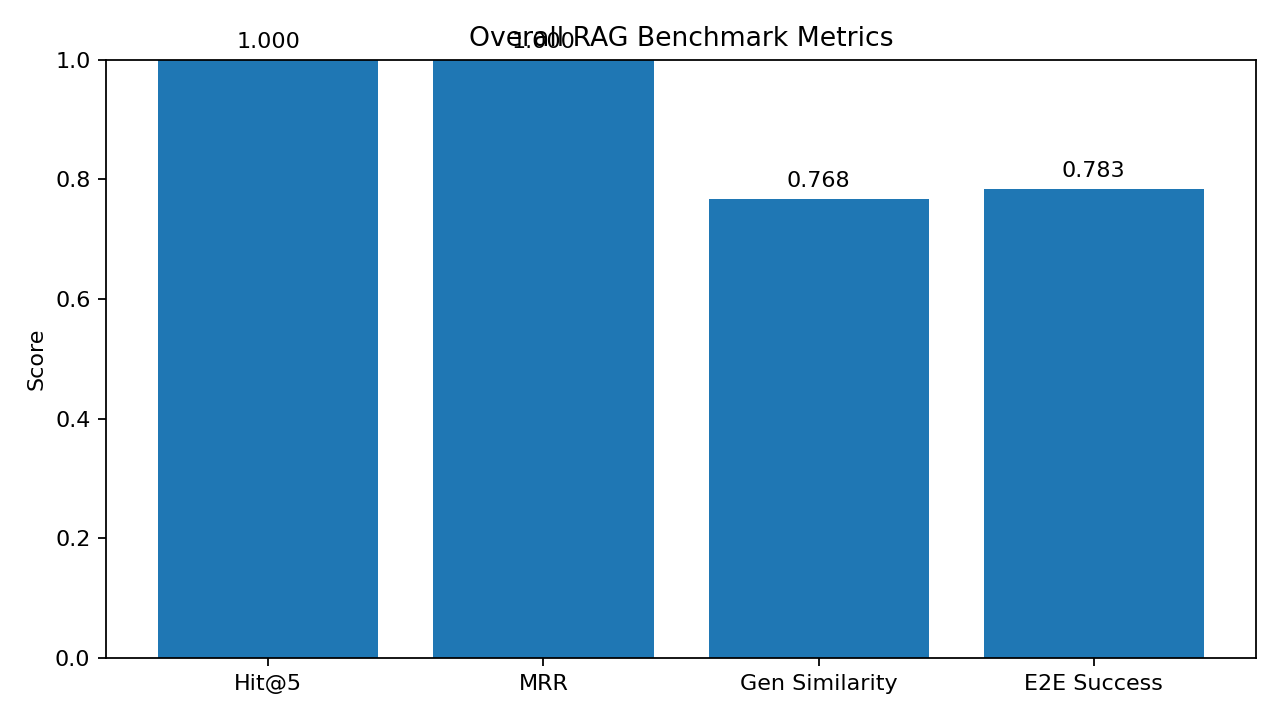

### failure_breakdown.png

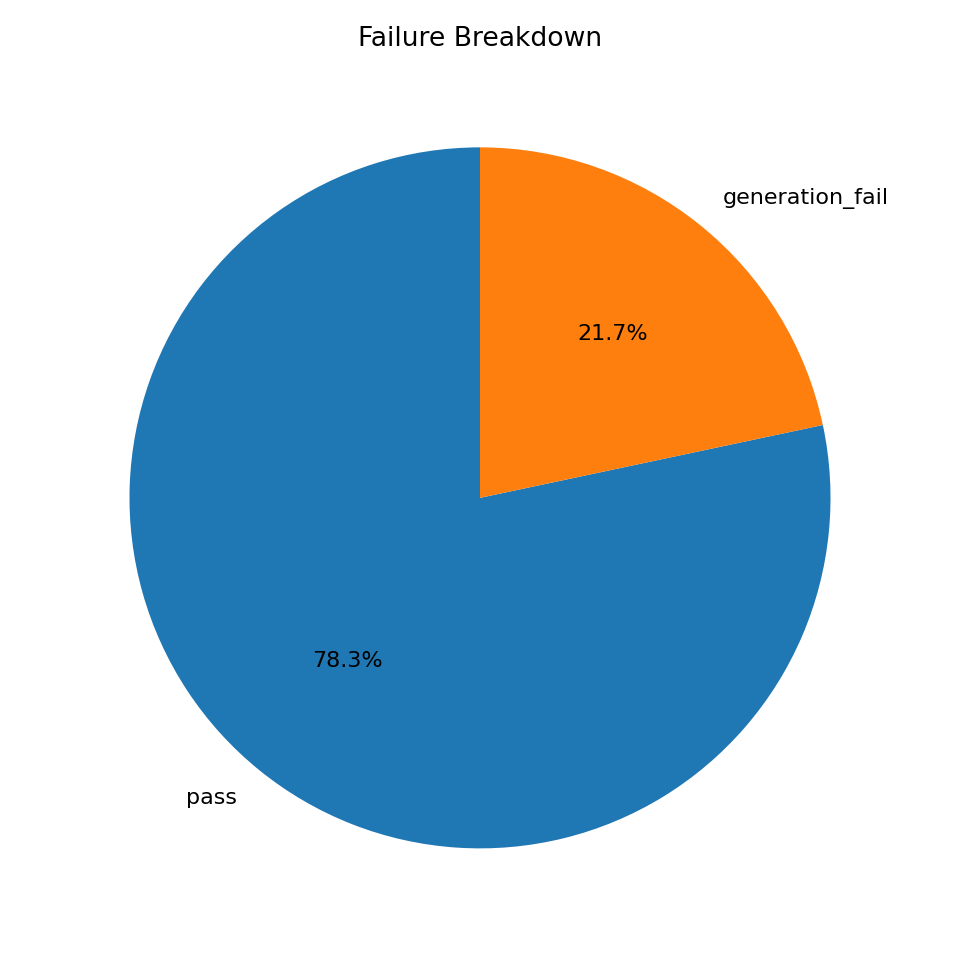

### similarity_distribution.png

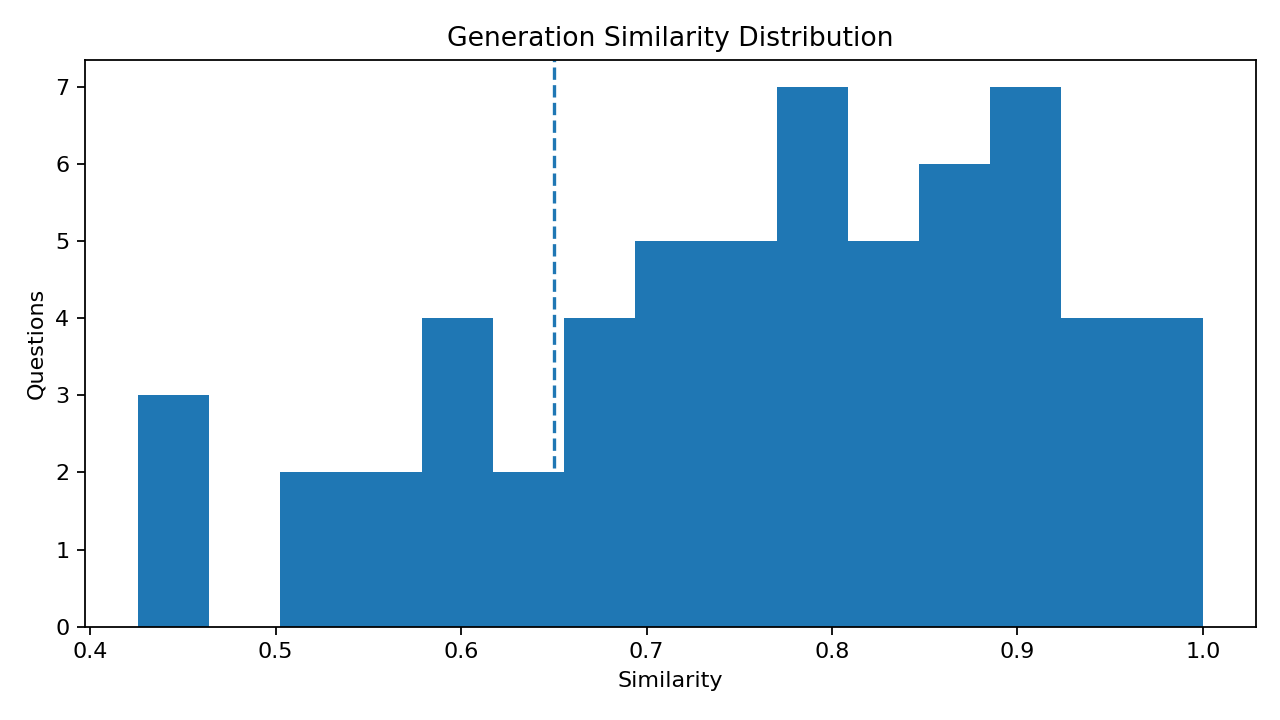

### e2e_by_srs.png

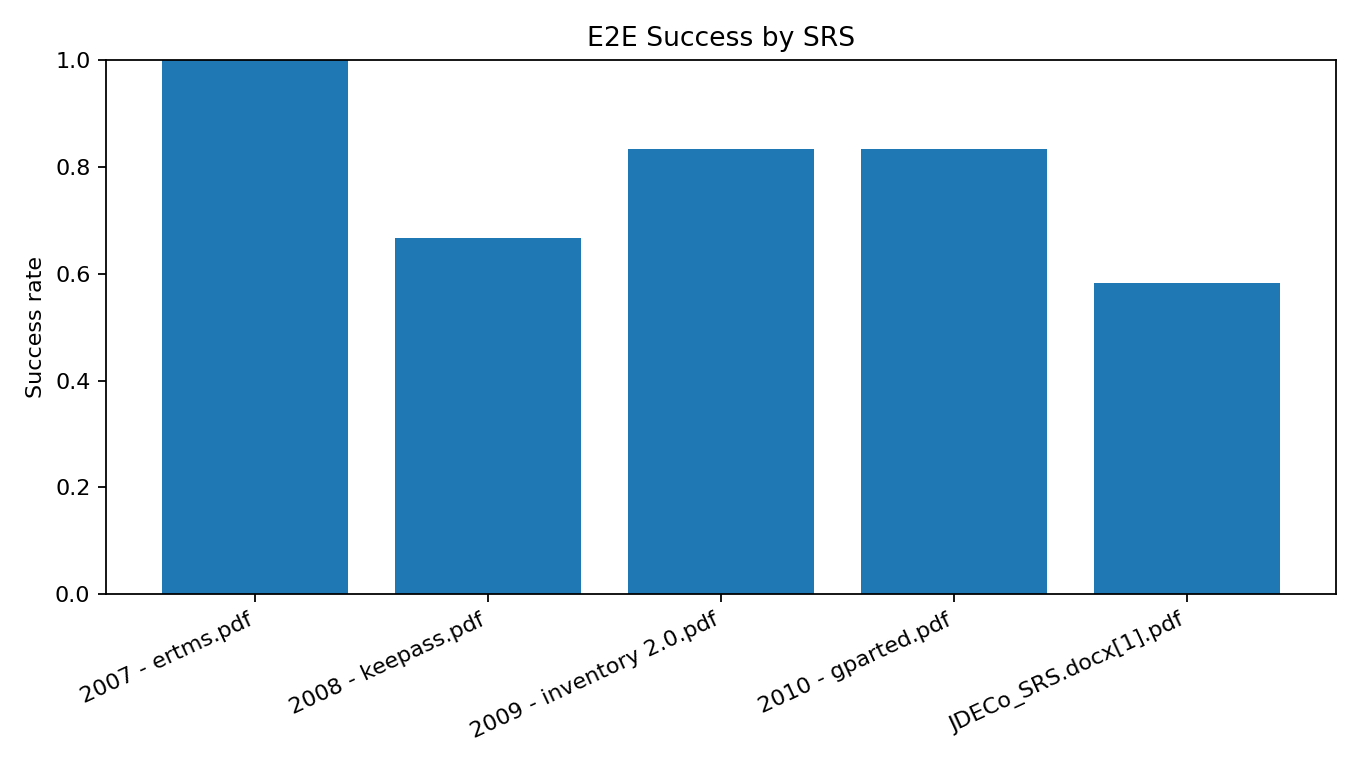

### e2e_by_category.png

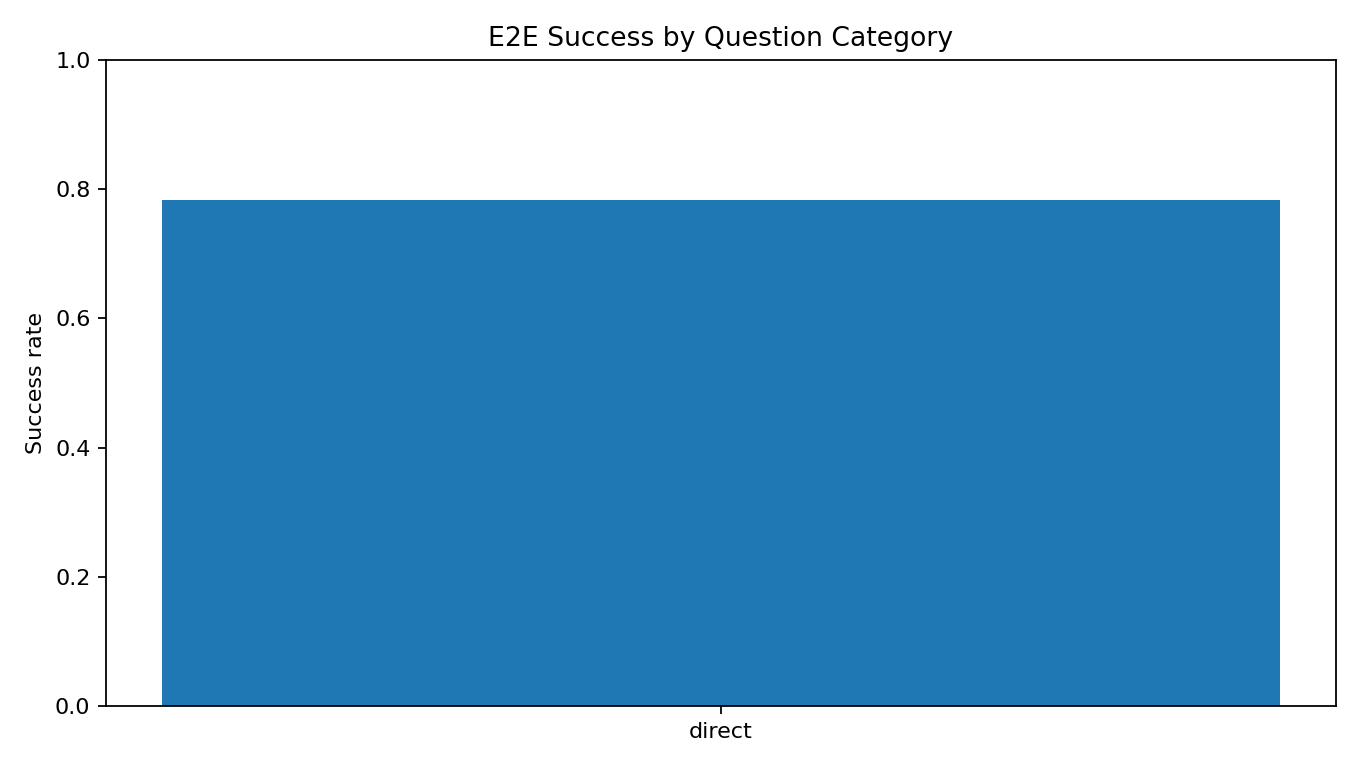

In [ ]:
plot_files = [
    "overall_metrics.png",
    "failure_breakdown.png",
    "similarity_distribution.png",
    "e2e_by_srs.png",
    "e2e_by_category.png",
]

for name in plot_files:
    p = REPORT / name
    display(Markdown(f"### {name}"))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f"Missing: {p}")

## Lowest Similarity Questions (Top 10)

This is the most actionable improvement list. Each row is a direct candidate for:
- Refining question wording (more specific and less ambiguous)
- Expanding `expected_answer` if it is too short/narrow
- Improving generation prompt behavior for incomplete responses

In [ ]:
top10_low = gen_by_q.sort_values("similarity", ascending=True).head(10)[
    ["question_id", "srs_file", "similarity", "expected_answer", "generated_answer"]
]
display(top10_low)

,question_id,srs_file,similarity,expected_answer,generated_answer
54,JDECO_4,JDECo_SRS.docx[1].pdf,0.425892,One of the most important feature in this syst...,An important feature in the JDECo Services Man...
17,KEEPASS_3,2008 - keepass.pdf,0.436598,The system is very small so it can be easily t...,KeePass is described as a small and light proj...
16,KEEPASS_2,2008 - keepass.pdf,0.460268,The system gives resolution to memorizing pass...,KeePass Password Safe solves the problem of ma...
18,KEEPASS_4,2008 - keepass.pdf,0.523305,"The database produced, is protected by a Maste...",The produced database in KeePass Password Safe...
42,GPARTED_4,2010 - gparted.pdf,0.525755,"It is a LiveCD application, which means it run...",GParted Live is a .zip or .iso file that you d...
50,JDECO_11,JDECo_SRS.docx[1].pdf,0.544401,"To access the product, users shall have an act...",To access the JDECo Services Management system...
38,GPARTED_11,2010 - gparted.pdf,0.569287,It is written in C++ and is based on the Debia...,GParted is based on the Debian GNU/Linux opera...
56,JDECO_6,JDECo_SRS.docx[1].pdf,0.583523,view where is the service now or stuck and the...,"In the JDECo Services Management system, the c..."
30,INV_4,2009 - inventory 2.0.pdf,0.584438,It also facilitates the process of receiving i...,Items are typically added to the inventory as ...
35,INV_9,2009 - inventory 2.0.pdf,0.593801,User is logged into the system,The pre-condition before viewing inventory is ...


## Similarity Bands Analysis

This analysis shows whether failures are severe or mostly close to the threshold (and therefore easier to improve).

,band,count,ratio
0,< 0.55,6,0.100000
1,0.55 - <0.65,7,0.116667
2,>= 0.65,47,0.783333


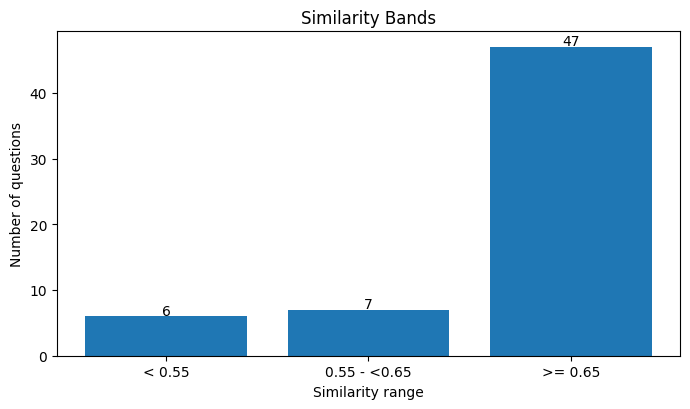

In [ ]:
bands = pd.DataFrame(
    [
        {"band": "< 0.55", "count": int((gen_by_q["similarity"] < 0.55).sum())},
        {
            "band": "0.55 - <0.65",
            "count": int(((gen_by_q["similarity"] >= 0.55) & (gen_by_q["similarity"] < 0.65)).sum()),
        },
        {"band": ">= 0.65", "count": int((gen_by_q["similarity"] >= 0.65).sum())},
    ]
)
bands["ratio"] = bands["count"] / max(1, len(gen_by_q))
display(bands)

plt.figure(figsize=(7, 4.2))
bars = plt.bar(bands["band"], bands["count"])
plt.title("Similarity Bands", fontsize=12)
plt.ylabel("Number of questions")
plt.xlabel("Similarity range")
for b, c in zip(bars, bands["count"]):
    plt.text(b.get_x() + b.get_width() / 2, c + 0.2, str(int(c)), ha="center")
plt.tight_layout()
plt.show()

## Additional Visual Explanations

These plots make the interpretation easier:
- Retrieval vs Generation vs E2E on one chart
- E2E success per SRS with value labels
- Generation similarity by SRS

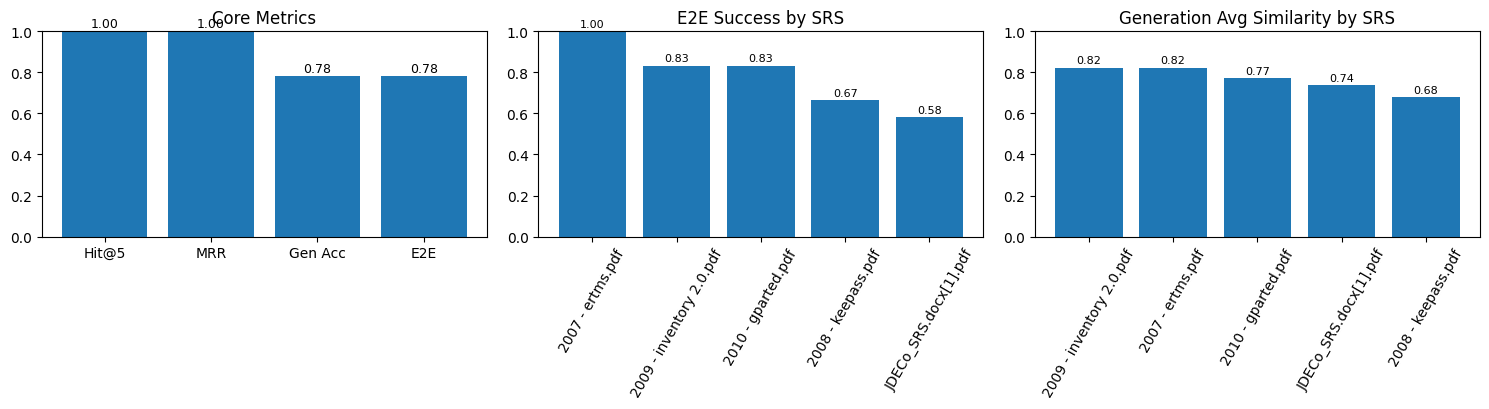

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# 1) Core metrics comparison
core_labels = ["Hit@5", "MRR", "Gen Acc", "E2E"]
core_vals = [
    float(overall_map.get("retrieval_hit@5", 0.0)),
    float(overall_map.get("retrieval_mrr", 0.0)),
    float(overall_map.get("generation_accuracy_sim>=0.65", 0.0)),
    float(overall_map.get("e2e_success_rate", 0.0)),
]
bars = axes[0].bar(core_labels, core_vals)
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Core Metrics")
for b, v in zip(bars, core_vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

# 2) E2E by SRS
x = e2e_by_srs.sort_values("e2e_success_rate", ascending=False)
bars2 = axes[1].bar(x["srs_file"], x["e2e_success_rate"])
axes[1].set_ylim(0, 1.0)
axes[1].set_title("E2E Success by SRS")
axes[1].tick_params(axis="x", rotation=60)
for b, v in zip(bars2, x["e2e_success_rate"]):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

# 3) Similarity by SRS
if "avg_similarity" in gen_by_srs.columns:
    gx = gen_by_srs.sort_values("avg_similarity", ascending=False)
    bars3 = axes[2].bar(gx["srs_file"], gx["avg_similarity"])
    axes[2].set_ylim(0, 1.0)
    axes[2].set_title("Generation Avg Similarity by SRS")
    axes[2].tick_params(axis="x", rotation=60)
    for b, v in zip(bars3, gx["avg_similarity"]):
        axes[2].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
else:
    axes[2].text(0.5, 0.5, "avg_similarity not available", ha="center", va="center")
    axes[2].set_title("Generation Avg Similarity by SRS")

plt.tight_layout()
plt.show()

## Actionable Recommendations

1. **Keep retrieval as is** (Hit@5 and MRR are already near-perfect).
2. **Focus on generation alignment** for low-similarity questions in the table above.
3. **Review threshold policy** (`0.65` is usually a balanced point for this dataset).
4. **Prioritize top-10 low-similarity questions** before broad prompt changes.
5. **Re-run benchmark after each batch of fixes** and track delta in generation accuracy and E2E success.